# Survey

In [1]:
import matplotlib.pyplot as plt

plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "text.latex.preamble": r"""
            \usepackage{times}
            \usepackage{amsmath}
        """,
        "font.size": 8,
        "legend.fontsize": 7,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
    }
)

## Feedback

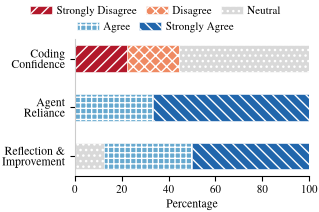

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# ====================================================
# 1. 动态布局配置与核心高度算法
# ====================================================
# 这里可以自由修改为 3 行、4 行或 5 行数据，布局会自动完美适配
categories = [
    "Coding\nConfidence",
    "Agent\nReliance",
    "Reflection \\&\nImprovement",
]

data_this = np.array(
    [
        [2 / 9, 2 / 9, 5 / 9, 0.0, 0.0],
        [0.0, 0.0, 0.0, 3 / 9, 6 / 9],
        [0.0, 0.0, 1 / 8, 3 / 8, 4 / 8],
    ]
)


bar_count = len(categories)
figsize_width = 3.35

# 算法核心：保持单柱及间距绝对物理高度为 0.354 英寸
# 同时预留 0.98 英寸供给两行图例、边框及底部 X 轴标签
figsize_height = round(0.98 + (0.354 * bar_count), 2)

# 全局字体配置
plt.rc("font", size=9)

labels = ["Strongly Disagree", "Disagree", "Neutral", "Agree", "Strongly Agree"]
colors = ["#b2182b", "#ef8a62", "#d9d9d9", "#67a9cf", "#2166ac"]
hatches = ["///", "xxx", "...", "+++", "\\\\\\"]

# ----------------------------------------------------
# 2. 创建动态画布
# ----------------------------------------------------
fig, ax = plt.subplots(figsize=(figsize_width, figsize_height))
left_this = np.zeros(bar_count)

# 3. 绘制堆叠条形图
for i in range(data_this.shape[1]):
    ax.barh(
        categories,
        data_this[:, i],
        left=left_this,
        color=colors[i],
        edgecolor="white",
        linewidth=0.4,
        hatch=hatches[i],
        height=0.55,  # 保持内部相对高度
    )
    left_this += data_this[:, i]

ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x*100:.0f}%"))
ax.invert_yaxis()

# 4. 细节美化与边框剔除
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.tick_params(axis="x", labelsize=8)
ax.tick_params(axis="y", labelsize=8.5)
ax.set_xlabel("Percentage", fontsize=8.5, labelpad=3)

# ----------------------------------------------------
# 【核心修正】动态调整图表顶端边界（Subplots Adjust）
# ----------------------------------------------------
# 逻辑：两行图例在绝对物理像素上大约占用 0.45 英寸的高度。
# 我们通过计算 0.45 英寸占总画布高度的比例，动态下压图表顶端，彻底绝缘重叠。
top_margin = round(1.0 - (0.45 / figsize_height), 3)
fig.subplots_adjust(
    top=top_margin,  # 动态为顶部的两行图例抠出绝对安全的物理空间
    left=0.26,  # 预留左侧文本标签空间
    right=0.96,  # 右侧微调留白
)

# ----------------------------------------------------
# 5. 图例两行居中对齐（坐标与图例间距无缝耦合）
# ----------------------------------------------------
handles = [c[0] for c in ax.containers]

# 保持第二行图例与第一行有固定物理微距（约 0.16 英寸）
leg2_y_anchor = round(0.99 - (0.16 / figsize_height), 3)

leg1 = fig.legend(
    handles[:3],
    labels[:3],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.99),  # 顶满画布最上缘
    ncol=3,
    frameon=False,
    fontsize=8,
    columnspacing=0.8,
    handletextpad=0.4,
)

leg2 = fig.legend(
    handles[3:],
    labels[3:],
    loc="upper center",
    bbox_to_anchor=(0.5, leg2_y_anchor),  # 动态紧跟第一行下方
    ncol=2,
    frameon=False,
    fontsize=8,
    columnspacing=0.8,
    handletextpad=0.4,
)

# ----------------------------------------------------
# 6. 导出设置
# ----------------------------------------------------
# 移除了 bbox_inches="tight"，改用真正的紧凑画布输出，确保柱子绝对物理等高且排版稳定
plt.savefig(
    "feedback.pdf",
    dpi=600,
    bbox_extra_artists=(leg1, leg2),
)
plt.show()

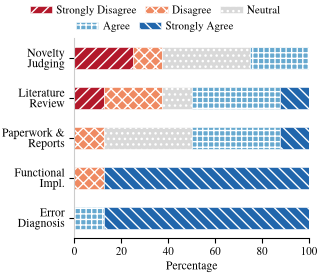

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# ====================================================
# 1. 动态布局配置与核心高度算法
# ====================================================
# 这里可以自由修改为 3 行、4 行或 5 行数据，布局会自动完美适配
categories = [
    "Novelty\nJudging",
    "Literature\nReview",
    "Paperwork \\&\nReports",
    "Functional\nImpl.",
    "Error\nDiagnosis",
]
data_this = np.array(
    [
        [2 / 8, 1 / 8, 3 / 8, 2 / 8, 0.0],
        [1 / 8, 2 / 8, 1 / 8, 3 / 8, 1 / 8],
        [0.0, 1 / 8, 3 / 8, 3 / 8, 1 / 8],
        [0.0, 1 / 8, 0.0, 0.0, 7 / 8],
        [0.0, 0.0, 0.0, 1 / 8, 7 / 8],
    ]
)


bar_count = len(categories)
figsize_width = 3.35

# 算法核心：保持单柱及间距绝对物理高度为 0.354 英寸
# 同时预留 0.98 英寸供给两行图例、边框及底部 X 轴标签
figsize_height = round(0.98 + (0.354 * bar_count), 2)

# 全局字体配置
plt.rc("font", size=9)

labels = ["Strongly Disagree", "Disagree", "Neutral", "Agree", "Strongly Agree"]
colors = ["#b2182b", "#ef8a62", "#d9d9d9", "#67a9cf", "#2166ac"]
hatches = ["///", "xxx", "...", "+++", "\\\\\\"]

# ----------------------------------------------------
# 2. 创建动态画布
# ----------------------------------------------------
fig, ax = plt.subplots(figsize=(figsize_width, figsize_height))
left_this = np.zeros(bar_count)

# 3. 绘制堆叠条形图
for i in range(data_this.shape[1]):
    ax.barh(
        categories,
        data_this[:, i],
        left=left_this,
        color=colors[i],
        edgecolor="white",
        linewidth=0.4,
        hatch=hatches[i],
        height=0.55,  # 保持内部相对高度
    )
    left_this += data_this[:, i]

ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x*100:.0f}%"))
ax.invert_yaxis()

# 4. 细节美化与边框剔除
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.tick_params(axis="x", labelsize=8)
ax.tick_params(axis="y", labelsize=8.5)
ax.set_xlabel("Percentage", fontsize=8.5, labelpad=3)

# ----------------------------------------------------
# 【核心修正】动态调整图表顶端边界（Subplots Adjust）
# ----------------------------------------------------
# 逻辑：两行图例在绝对物理像素上大约占用 0.45 英寸的高度。
# 我们通过计算 0.45 英寸占总画布高度的比例，动态下压图表顶端，彻底绝缘重叠。
top_margin = round(1.0 - (0.45 / figsize_height), 3)
fig.subplots_adjust(
    top=top_margin,  # 动态为顶部的两行图例抠出绝对安全的物理空间
    left=0.26,  # 预留左侧文本标签空间
    right=0.96,  # 右侧微调留白
)

# ----------------------------------------------------
# 5. 图例两行居中对齐（坐标与图例间距无缝耦合）
# ----------------------------------------------------
handles = [c[0] for c in ax.containers]

# 保持第二行图例与第一行有固定物理微距（约 0.16 英寸）
leg2_y_anchor = round(0.99 - (0.16 / figsize_height), 3)

leg1 = fig.legend(
    handles[:3],
    labels[:3],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.99),  # 顶满画布最上缘
    ncol=3,
    frameon=False,
    fontsize=8,
    columnspacing=0.8,
    handletextpad=0.4,
)

leg2 = fig.legend(
    handles[3:],
    labels[3:],
    loc="upper center",
    bbox_to_anchor=(0.5, leg2_y_anchor),  # 动态紧跟第一行下方
    ncol=2,
    frameon=False,
    fontsize=8,
    columnspacing=0.8,
    handletextpad=0.4,
)

# ----------------------------------------------------
# 6. 导出设置
# ----------------------------------------------------
# 移除了 bbox_inches="tight"，改用真正的紧凑画布输出，确保柱子绝对物理等高且排版稳定
plt.savefig(
    "usage.pdf",
    dpi=600,
    bbox_extra_artists=(leg1, leg2),
)
plt.show()

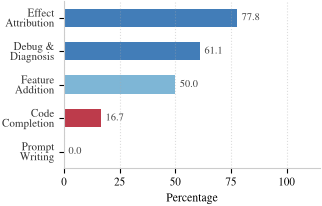

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------
# 图 (a) 专用导出：Actual Support Provided
# ----------------------------------------------------
actual_labels = [
    "Effect\nAttribution",
    "Debug \\&\nDiagnosis",
    "Feature\nAddition",
    "Code\nCompletion",
    "Prompt\nWriting",
]
actual_pct = [77.8, 61.1, 50.0, 16.7, 0.0]
colors_actual = ["#2166ac", "#2166ac", "#67a9cf", "#b2182b", "#b2182b"]  # 纯色，无hatch

fig, ax1 = plt.subplots(figsize=(3.45, 2.3))  # 精准控制单栏黄金宽高比
y_pos1 = np.arange(len(actual_labels))
bars1 = ax1.barh(
    y_pos1, actual_pct, color=colors_actual, alpha=0.85, height=0.55, edgecolor="none"
)
ax1.set_yticks(y_pos1)
ax1.set_yticklabels(actual_labels, fontsize=8, fontweight="bold", color="#333333")
ax1.invert_yaxis()
ax1.set_xlim(0, 115)
ax1.set_xticks([0, 25, 50, 75, 100])
ax1.set_xticklabels(["0%", "25%", "50%", "75%", "100%"], fontsize=8)
ax1.set_xlabel("Percentage", fontsize=8.5)

for bar in bars1:
    width = bar.get_width()
    ax1.text(
        width + 2,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        ha="left",
        fontsize=7.5,
        color="#444444",
        fontweight="bold",
    )

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["left"].set_color("#cccccc")
ax1.spines["bottom"].set_color("#cccccc")
ax1.grid(axis="x", linestyle=":", alpha=0.4, color="#aaaaaa")

plt.tight_layout()
plt.savefig("difficulty.pdf", bbox_inches="tight", dpi=600)
plt.show()

## Time Spent

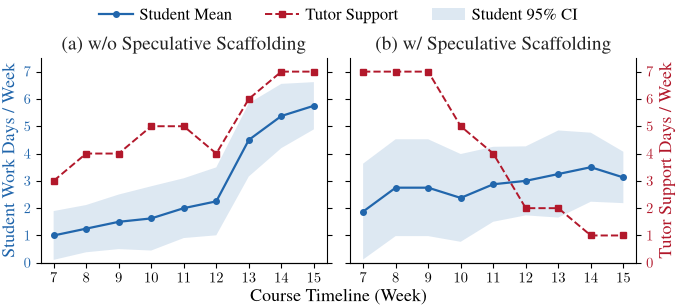

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from matplotlib.patches import Patch

WEEK_BASIC_END = 6


# ----------------------------------------------------
# 1. 原始数据准备与统计还原函数
# ----------------------------------------------------
def restore_and_calc_ci(work_day_dist):
    student_means = []
    student_ci_lower = []
    student_ci_upper = []
    day_values = np.arange(8)

    for row in work_day_dist:
        raw_samples = np.repeat(day_values, row)
        mean = np.mean(raw_samples)
        student_means.append(mean)

        n = len(raw_samples)
        sem = stats.sem(raw_samples)
        if sem > 0:
            h = sem * stats.t.ppf((1 + 0.95) / 2.0, n - 1)
            student_ci_lower.append(max(0, mean - h))
            student_ci_upper.append(min(7, mean + h))
        else:
            student_ci_lower.append(mean)
            student_ci_upper.append(mean)
    return student_means, student_ci_lower, student_ci_upper


# --- [左图：Baseline Offering 数据] ---
dist_baseline = [
    [3, 3, 1, 1, 0, 0, 0, 0],
    [2, 3, 2, 1, 0, 0, 0, 0],
    [2, 2, 2, 2, 0, 0, 0, 0],
    [2, 2, 2, 1, 1, 0, 0, 0],
    [1, 2, 2, 2, 1, 0, 0, 0],
    [1, 2, 1, 2, 2, 0, 0, 0],
    [0, 0, 1, 1, 2, 2, 1, 1],
    [0, 0, 0, 1, 1, 2, 2, 2],
    [0, 0, 0, 0, 1, 2, 3, 2],
]
tutor_baseline = [3, 4, 4, 5, 5, 4, 6, 7, 7]

# --- [右图：Experimental Offering 数据] ---
dist_experimental = [
    [2, 3, 1, 0, 1, 0, 1, 0],
    [1, 2, 1, 1, 1, 1, 1, 0],
    [1, 2, 1, 1, 1, 1, 1, 0],
    [1, 2, 2, 1, 1, 0, 1, 0],
    [0, 2, 2, 1, 1, 2, 0, 0],
    [0, 1, 3, 1, 1, 2, 0, 0],
    [0, 1, 3, 1, 1, 0, 2, 0],
    [0, 1, 1, 2, 1, 3, 0, 0],
    [0, 1, 1, 2, 4, 0, 0, 0],
]
tutor_experimental = [7, 7, 7, 5, 4, 2, 2, 1, 1]

weeks = np.arange(1, len(tutor_baseline) + 1) + WEEK_BASIC_END
base_means, base_ci_low, base_ci_up = restore_and_calc_ci(dist_baseline)
exp_means, exp_ci_low, exp_ci_up = restore_and_calc_ci(dist_experimental)

# ----------------------------------------------------
# 2. 画布创建 (跨双栏的标准比例)
# ----------------------------------------------------
figsize_width = 7.0  # 完美适配 ACM page text width
figsize_height = 3.0  # 稍微压低高度，留出更多空间给论文正文
fig_axes: tuple[plt.Figure, tuple[plt.Axes, ...]] = plt.subplots(
    1, 2, figsize=(figsize_width, figsize_height), sharex=True
)
fig, (ax1, ax3) = fig_axes

color_student = "#2166ac"
color_tutor = "#b2182b"

# ====================================================
# 3. 绘制左图：Baseline Offering
# ====================================================
ax1.set_title(
    "(a) w/o Speculative Scaffolding", fontsize=14, fontweight="bold", color="#222222", pad=6
)
# 🔍 左图保留左轴标签
ax1.set_ylabel("Student Work Days / Week", color=color_student, fontsize=13)

ax1.fill_between(
    weeks, base_ci_low, base_ci_up, color=color_student, alpha=0.15, edgecolor="none"
)
(line_student,) = ax1.plot(
    weeks, base_means, color=color_student, marker="o", linewidth=1.6, markersize=4
)
ax1.tick_params(axis="y", labelcolor=color_student, labelsize=10.5)
ax1.set_ylim(0, 7.5)
ax1.set_yticks(range(8))

# 左图右轴（隐藏文字）
ax2 = ax1.twinx()
(line_tutor,) = ax2.plot(
    weeks,
    tutor_baseline,
    color=color_tutor,
    marker="s",
    linestyle="--",
    linewidth=1.4,
    markersize=4,
)
ax2.set_ylabel("")
ax2.set_yticklabels([])
ax2.tick_params(axis="y", which="both", right=True, labelright=False)
ax2.set_ylim(0, 7.5)
ax2.set_yticks(range(8))

# ====================================================
# 4. 绘制右图：Experimental Offering
# ====================================================
ax3.set_title(
    "(b) w/ Speculative Scaffolding", fontsize=14, fontweight="bold", color="#222222", pad=6
)
# 🔍 右图隐藏左轴标签和刻度
ax3.set_ylabel("")
ax3.set_yticklabels([])
ax3.tick_params(axis="y", which="both", left=False)

ax3.fill_between(
    weeks, exp_ci_low, exp_ci_up, color=color_student, alpha=0.15, edgecolor="none"
)
ax3.plot(weeks, exp_means, color=color_student, marker="o", linewidth=1.6, markersize=4)
ax3.set_ylim(0, 7.5)
ax3.set_yticks(range(8))

# 右图右轴（保留标签）
ax4 = ax3.twinx()
ax4.plot(
    weeks,
    tutor_experimental,
    color=color_tutor,
    marker="s",
    linestyle="--",
    linewidth=1.4,
    markersize=4,
)
ax4.set_ylabel("Tutor Support Days / Week", color=color_tutor, fontsize=13)
ax4.tick_params(axis="y", labelcolor=color_tutor, labelsize=10.5)
ax4.set_ylim(0, 7.5)
ax4.set_yticks(range(8))

# ----------------------------------------------------
# 5. 边框细节美化
# ----------------------------------------------------
for ax in [ax1, ax2, ax3, ax4]:
    ax.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)
ax3.spines["right"].set_visible(False)
ax4.spines["left"].set_visible(False)

for ax in [ax1, ax3]:
    ax.set_xticks(weeks)
    ax.tick_params(axis="x", labelsize=10.5)

# ----------------------------------------------------
# 6. 全局顶置展平图例
# ----------------------------------------------------
labels = ["Student Mean", "Tutor Support", "Student 95\\% CI"]
legend_elements = [
    line_student,
    line_tutor,
    Patch(facecolor=color_student, alpha=0.15, edgecolor="none"),
]

fig.legend(
    legend_elements,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=False,
    fontsize=12,
    handletextpad=0.4,
    columnspacing=2.0,
)

# 为顶部的统一图例留出精确空间
plt.tight_layout(rect=[0, 0, 1, 0.92])

fig.supxlabel("Course Timeline (Week)", fontsize=13, y=-0.02)

# 📥 导出完美适配 ACM 模板的 PDF
plt.savefig("overhead.pdf", bbox_inches="tight", dpi=600)
plt.show()

## Support

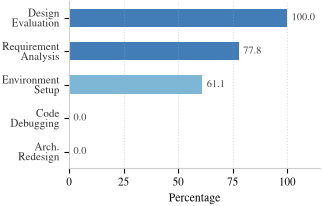

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------
# 图 (a) 专用导出：Actual Support Provided
# ----------------------------------------------------
actual_labels = [
    "Design\nEvaluation",
    "Requirement\nAnalysis",
    "Environment\nSetup",
    "Code\nDebugging",
    "Arch.\nRedesign",
]
actual_pct = [100.0, 77.8, 61.1, 0.0, 0.0]
colors_actual = ["#2166ac", "#2166ac", "#67a9cf", "#b2182b", "#b2182b"]  # 纯色，无hatch

fig, ax1 = plt.subplots(figsize=(3.45, 2.3))  # 精准控制单栏黄金宽高比
y_pos1 = np.arange(len(actual_labels))
bars1 = ax1.barh(
    y_pos1, actual_pct, color=colors_actual, alpha=0.85, height=0.55, edgecolor="none"
)
ax1.set_yticks(y_pos1)
ax1.set_yticklabels(actual_labels, fontsize=8, fontweight="bold", color="#333333")
ax1.invert_yaxis()
ax1.set_xlim(0, 115)
ax1.set_xticks([0, 25, 50, 75, 100])
ax1.set_xticklabels(["0%", "25%", "50%", "75%", "100%"], fontsize=8)
ax1.set_xlabel("Percentage", fontsize=8.5)

for bar in bars1:
    width = bar.get_width()
    ax1.text(
        width + 2,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        ha="left",
        fontsize=7.5,
        color="#444444",
        fontweight="bold",
    )

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["left"].set_color("#cccccc")
ax1.spines["bottom"].set_color("#cccccc")
ax1.grid(axis="x", linestyle=":", alpha=0.4, color="#aaaaaa")

plt.tight_layout()
plt.savefig("support_actual.pdf", bbox_inches="tight", dpi=600)
plt.show()

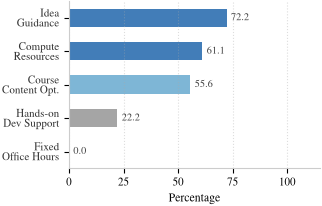

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------
# 图 (b) 专用导出：Additional Support Requested
# ----------------------------------------------------
desired_labels = [
    "Idea\nGuidance",
    "Compute\nResources",
    "Course\nContent Opt.",
    "Hands-on\nDev Support",
    "Fixed\nOffice Hours",
]
desired_pct = [72.2, 61.1, 55.6, 22.2, 0.0]
colors_desired = [
    "#2166ac",
    "#2166ac",
    "#67a9cf",
    "#969696",
    "#969696",
]

fig, ax2 = plt.subplots(figsize=(3.45, 2.3))
y_pos2 = np.arange(len(desired_labels))
bars2 = ax2.barh(
    y_pos2, desired_pct, color=colors_desired, alpha=0.85, height=0.55, edgecolor="none"
)
ax2.set_yticks(y_pos2)
ax2.set_yticklabels(desired_labels, fontsize=8, fontweight="bold", color="#333333")
ax2.invert_yaxis()
ax2.set_xlim(0, 115)
ax2.set_xticks([0, 25, 50, 75, 100])
ax2.set_xticklabels(["0%", "25%", "50%", "75%", "100%"], fontsize=8)
ax2.set_xlabel("Percentage", fontsize=8.5)

for bar in bars2:
    width = bar.get_width()
    ax2.text(
        width + 2,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        ha="left",
        fontsize=7.5,
        color="#444444",
        fontweight="bold",
    )

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_color("#cccccc")
ax2.spines["bottom"].set_color("#cccccc")
ax2.grid(axis="x", linestyle=":", alpha=0.4, color="#aaaaaa")

plt.tight_layout()
plt.savefig("support_desired.pdf", bbox_inches="tight", dpi=600)
plt.show()